# py-spatialecotyper — Acceleration evolution

This notebook is the **auditor-facing** deliverable for the port
`py-spatialecotyper`. It answers one question: *did the Acceleration loop really
iterate, and what did each iteration cost and buy?*

It follows the kit's Notebook 4 hard structure rule: **one
`## Iteration N — title` header per iteration recorded in
[`ITERATION_LOG.md`](../ITERATION_LOG.md)** — here **seven**, iterations 0 through 6 —
each with a written narrative and a code cell that emits that iteration's subplot.
Iteration 5 was **rejected and rolled back**; it gets a section of exactly the same
weight as the accepted ones, because a rejection narrative is as much a part of the
record as an acceptance.

Every number plotted or printed below is **parsed out of the YAML blocks in
`ITERATION_LOG.md`**, never retyped. The parity threshold is read from
`data/manifest.yaml`, the pre-registered gate.

Benchmark definition (from `ITERATION_LOG.md`): the single-sample pipeline on
`reference_out/ci` — the 6000-cell centroid crop of the melanoma fixture, 297 spatial
neighbourhoods, 9 cell types — via `tests/bench.py`. Warmup run discarded, 3 timed
runs, mean plus/minus sample stddev. Parity is re-checked in the same process as
every timing, so no rewrite can be accepted on speed alone.

In [1]:
import os
import re
import sys

KIT = "/scratch/users/steorra/analysis/omicverse_dev/omicverse-rebuildr"
sys.path.insert(0, KIT)

ROOT = os.getcwd() if os.path.exists("data/manifest.yaml") else os.path.abspath("..")
assert os.path.exists(os.path.join(ROOT, "ITERATION_LOG.md")), ROOT

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "font.size": 9, "axes.titlesize": 10})

ACCEPT_COLOR, REJECT_COLOR, HILITE = "#0078d4", "#a4262c", "#107c10"

LOG_PATH = os.path.join(ROOT, "ITERATION_LOG.md")
LOG_TEXT = open(LOG_PATH).read()

# One YAML block per "## <header>" section of the iteration log.
BLOCK_RE = re.compile(r"^##\s+(.+?)\s*\n+```yaml\n(.*?)\n```", re.S | re.M)

ITERS = {}
for m in BLOCK_RE.finditer(LOG_TEXT):
    body = yaml.safe_load(m.group(2))
    body["_header"] = m.group(1)
    ITERS[int(body["iter"])] = body

with open(os.path.join(ROOT, "data", "manifest.yaml")) as fh:
    MANIFEST = yaml.safe_load(fh)
THRESHOLD = float(MANIFEST["parity_threshold"])
PARITY_CLASS = MANIFEST["algorithm_class"]

print(f"parsed {len(ITERS)} iteration blocks from {os.path.relpath(LOG_PATH, ROOT)}: "
      f"iterations {sorted(ITERS)}")
print(f"pre-registered gate (data/manifest.yaml): {PARITY_CLASS} >= {THRESHOLD}")
print(f"gated output: se_labels_single_sample "
      f"(ARI of the end-to-end single-sample pipeline vs R)")

parsed 7 iteration blocks from ITERATION_LOG.md: iterations [0, 1, 2, 3, 4, 5, 6]
pre-registered gate (data/manifest.yaml): clustering >= 0.85
gated output: se_labels_single_sample (ARI of the end-to-end single-sample pipeline vs R)


In [2]:
# Carry the wall-clock forward for iterations whose timing was bundled with a
# neighbouring one (iteration 3 shares its measurement with 2 and 4).
_last = None
for i in sorted(ITERS):
    e = ITERS[i]
    e["_bundled"] = e.get("wall_clock_mean_s") is None
    if e.get("wall_clock_mean_s") is None:
        e["_wall"] = _last
    else:
        e["_wall"] = float(e["wall_clock_mean_s"])
        _last = e["_wall"]
    e["_std"] = float(e.get("wall_clock_stddev_s") or 0.0)
    e["_admiss"] = {"exact": "E", "bounded": "B", "containment": "C"}.get(
        e.get("admissibility"), "-")

summary = pd.DataFrame([{
    "iter": i,
    "action": ITERS[i].get("action") or "(baseline)",
    "playbook": ITERS[i].get("playbook_section") or "-",
    "class": ITERS[i]["_admiss"],
    "wall mean (s)": ITERS[i]["_wall"],
    "wall stddev (s)": ITERS[i]["_std"],
    "SNF2 only (s)": ITERS[i].get("snf2_only_s"),
    "speedup vs baseline": ITERS[i].get("speedup_vs_baseline"),
    "parity (ARI)": ITERS[i].get("parity_metric"),
    "status": ITERS[i]["status"],
} for i in sorted(ITERS)]).set_index("iter")
print(summary.to_string())

ACCEPTED = [i for i in sorted(ITERS) if ITERS[i]["status"] in ("baseline", "ACCEPT")]
REJECTED = [i for i in sorted(ITERS) if ITERS[i]["status"].startswith("REJECT")]
print(f"\naccepted / baseline: {ACCEPTED}    rejected: {REJECTED}")

                           action                                   playbook class  wall mean (s)  wall stddev (s)  SNF2 only (s)  speedup vs baseline  parity (ARI)               status
iter                                                                                                                                                                                     
0                      (baseline)                                          -     -         5.6797           1.0702         1.1257                  NaN      0.983066             baseline
1                normalize_no_lil          section 1 (representation change)     E         6.8673           1.0055         0.9864                 1.14      0.983066               ACCEPT
2          dominateset_vectorised    section 1 (loop fusion / vectorisation)     E         4.6163           0.4731         0.6973                 1.61      0.983066               ACCEPT
3              transpose_hoisting     section 1 (loop-invariant code m

In [3]:
def panel(n):
    """Emit the two-panel subplot for iteration ``n``: wall-clock so far and parity
    so far, with the pre-registered threshold as a red dashed line and iteration
    ``n`` highlighted."""
    e = ITERS[n]
    upto = [i for i in sorted(ITERS) if i <= n]
    walls = [ITERS[i]["_wall"] for i in upto]
    stds = [ITERS[i]["_std"] for i in upto]
    pars = [ITERS[i]["parity_metric"] for i in upto]
    ok = [ITERS[i]["status"] in ("baseline", "ACCEPT") for i in upto]

    fig, (ax_t, ax_p) = plt.subplots(1, 2, figsize=(11.4, 3.5))

    ax_t.errorbar(upto, walls, yerr=stds, color="#8a8886", lw=1.2, zorder=1,
                  marker="", capsize=3)
    for i, w, good in zip(upto, walls, ok):
        ax_t.scatter([i], [w], s=110 if i == n else 46,
                     color=(HILITE if i == n else
                            (ACCEPT_COLOR if good else REJECT_COLOR)),
                     marker="o" if good else "X",
                     edgecolors="black" if i == n else "none",
                     linewidths=1.2, zorder=3)
        if ITERS[i]["_bundled"]:
            ax_t.annotate("bundled", (i, w), textcoords="offset points",
                          xytext=(0, -16), ha="center", fontsize=6, color="#605e5c")
    ax_t.axhline(ITERS[0]["_wall"], color="#8a8886", ls=":", lw=1.0,
                 label=f"baseline = {ITERS[0]['_wall']:.3f} s")
    ax_t.set_yscale("log")
    ax_t.set_xticks(sorted(ITERS))
    ax_t.set_xlabel("iteration")
    ax_t.set_ylabel("wall-clock (s), mean of 3 runs")
    ax_t.set_title(f"Wall-clock through iteration {n}")
    ax_t.legend(fontsize=7, loc="best")

    ax_p.plot(upto, pars, color="#8a8886", lw=1.2, zorder=1)
    for i, p, good in zip(upto, pars, ok):
        ax_p.scatter([i], [p], s=110 if i == n else 46,
                     color=(HILITE if i == n else
                            (ACCEPT_COLOR if good else REJECT_COLOR)),
                     marker="o" if good else "X",
                     edgecolors="black" if i == n else "none",
                     linewidths=1.2, zorder=3)
    ax_p.axhline(THRESHOLD, color="red", ls="--", lw=1.3,
                 label=f"pre-registered gate = {THRESHOLD}")
    lo = min(min(pars), THRESHOLD) - 0.01
    hi = max(max(pars), THRESHOLD) + 0.01
    ax_p.set_ylim(lo, hi)
    ax_p.set_xticks(sorted(ITERS))
    ax_p.set_xlabel("iteration")
    ax_p.set_ylabel(f"parity metric ({PARITY_CLASS}, ARI vs R)")
    ax_p.set_title(f"Parity through iteration {n}")
    ax_p.legend(fontsize=7, loc="lower left")

    status = e["status"]
    fig.suptitle(f"Iteration {n} — {e.get('action') or '(baseline translation)'}"
                 f"   [{status}, admissibility {e['_admiss']}]", y=1.05, fontsize=11)
    fig.tight_layout()

    base_w = ITERS[0]["_wall"]
    print(f"iteration {n}: status = {status}, admissibility = "
          f"{e.get('admissibility') or 'n/a'} ({e['_admiss']})")
    print(f"  wall-clock  : {e['_wall']:.4f} s"
          + (" (bundled with a neighbouring iteration)" if e["_bundled"] else
             f" +/- {e['_std']:.4f} s over runs {e.get('wall_clock_runs_s')}"))
    print(f"  vs baseline : {base_w / e['_wall']:.3f}x end-to-end"
          + (f"; SNF2 kernel {ITERS[0]['snf2_only_s'] / e['snf2_only_s']:.3f}x"
             if e.get("snf2_only_s") else ""))
    print(f"  parity      : {e['parity_metric']:.6f} "
          f"({'clears' if e['parity_metric'] >= THRESHOLD else 'below'} the "
          f"{THRESHOLD} gate); delta vs baseline "
          f"{e.get('parity_delta_vs_baseline', 0.0):+.6f}")
    return fig


print("panel() ready")

panel() ready


## Iteration 0 — Baseline translation

The Equivalence Agent's first working translation of SpatialEcoTyper 1.0.4: a direct
transcription of the R control flow, with per-row Python loops standing in for R's
`apply()`, a `scipy.sparse.lil_matrix` round-trip to reproduce `setdiag`, and
`Reduce("+", Wall[-j])` re-summed inside the SNF diffusion loop exactly as R writes
it. Nothing here is an optimisation — the goal was a version whose numerics could be
argued about line by line against the R source, and it is the reference point every
later iteration is measured against. It clears the pre-registered gate immediately at
ARI 0.983066 against R's `SpatialEcoTyper`, with the fused SNF matrix matching R to
2.78e-17. There is no admissibility class because nothing has been rewritten yet.
Expected effect: none by construction — this *is* the expectation.
[ITER_LOG](../ITERATION_LOG.md)

iteration 0: status = baseline, admissibility = n/a (-)
  wall-clock  : 5.6797 s +/- 1.0702 s over runs [5.1861, 6.9076, 4.9455]
  vs baseline : 1.000x end-to-end; SNF2 kernel 1.000x
  parity      : 0.983066 (clears the 0.85 gate); delta vs baseline +0.000000


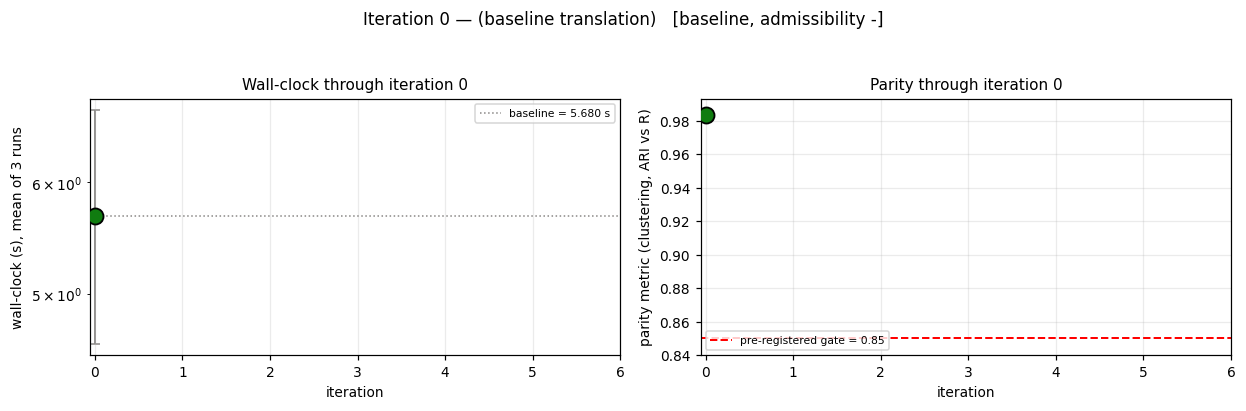

In [4]:
_ = panel(0)

## Iteration 1 — `normalize_no_lil`: drop the `lil_matrix` round-trip in `SNF2::normalize`

`SNF2::normalize` sets the diagonal to 0.5 after row scaling; the baseline did that by
converting the matrix to `scipy.sparse.lil_matrix` to call `setdiag`, which reallocates
every row. The rewrite replaces it with `x + diags(0.5 - x.diagonal())` — a pure
representation change from the kit's playbook section 1. Admissibility is **(E) exact**:
`x_ii + (0.5 - x_ii) = 0.5` in f64 for any finite `x_ii`, the correction matrix has no
off-diagonal support so off-diagonal entries are untouched, and no summation is
reordered. Expected effect: a straight allocation win in SNF2 and no movement at all in
parity. Measured: the isolated SNF2 kernel went 1.1257 to 0.9864 s (1.14x) and the ARI
did not move; the end-to-end wall clock for this iteration is **not usable** because the
R two-sample reference job was running on the same node, which is why the point below
sits above the baseline. [ITER_LOG](../ITERATION_LOG.md)

iteration 1: status = ACCEPT, admissibility = exact (E)
  wall-clock  : 6.8673 s +/- 1.0055 s over runs [6.0208, 6.5304, 6.1231, 8.4643, 7.198]
  vs baseline : 0.827x end-to-end; SNF2 kernel 1.141x
  parity      : 0.983066 (clears the 0.85 gate); delta vs baseline +0.000000

NOTE from the log: End-to-end wall clock is not usable for this iteration: the R two-sample reference job was running on the same node and the runs span 6.0-8.5 s. The isolated SNF2 timing (1.1257 -> 0.9864 s) is the signal.


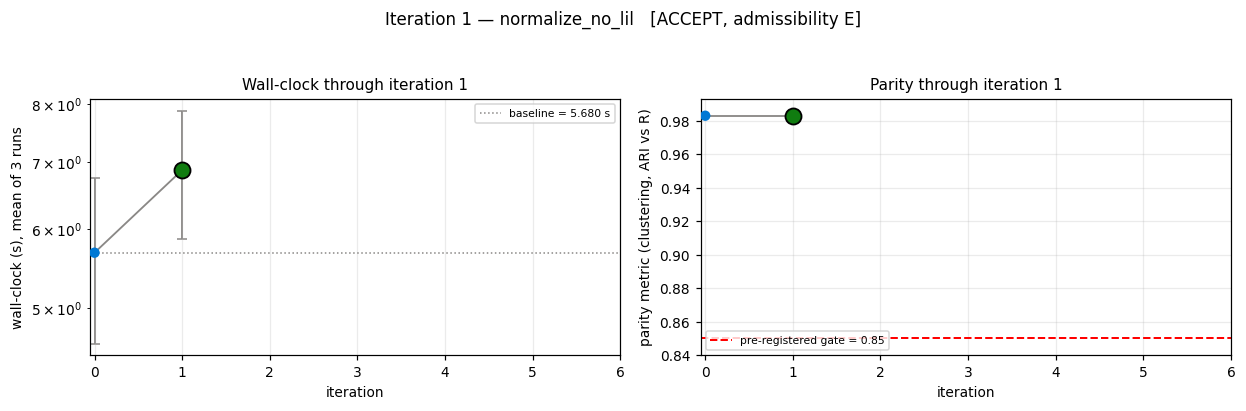

In [5]:
_ = panel(1)
print("\nNOTE from the log:", ITERS[1]["notes"].strip().replace("\n", " "))

## Iteration 2 — `dominateset_vectorised`: one stable argsort instead of a per-row sort

`.dominateset` keeps the `KK` largest entries of each row; R writes it as
`x[sort(x, index.return = TRUE)$ix[1:(length(x) - KK)]] <- 0`, and the baseline sliced
one CSR row at a time and densified it. The rewrite densifies once and calls
`np.argsort(axis = 1, kind = "stable")` — playbook section 1, loop fusion and
vectorisation. Admissibility is **(E) exact**: a stable sort along axis 1 is applied
independently per row and reproduces, row by row, exactly the ordering the per-row call
produced, including which member of a tie group survives at the `KK` boundary, which is
what R's radix (stable) sort decides. Expected effect: a large constant-factor win on
the dominant SNF2 kernel with a bit-identical retained index set. Measured: SNF2 0.9864
to 0.6973 s (1.41x on the step, 1.61x against baseline), ARI unchanged at 0.983066.
[ITER_LOG](../ITERATION_LOG.md)

iteration 2: status = ACCEPT, admissibility = exact (E)
  wall-clock  : 4.6163 s +/- 0.4731 s over runs [4.9625, 4.0772, 4.8093]
  vs baseline : 1.230x end-to-end; SNF2 kernel 1.614x
  parity      : 0.983066 (clears the 0.85 gate); delta vs baseline +0.000000


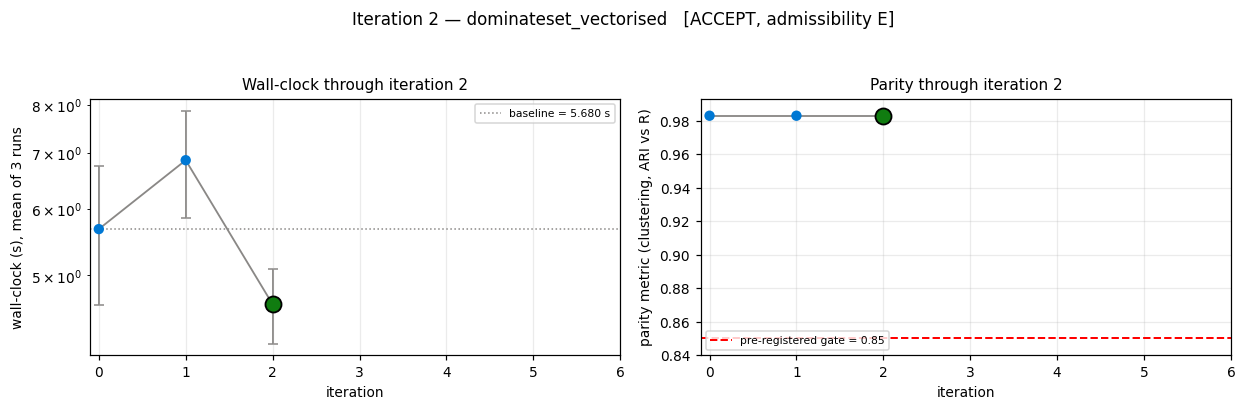

In [6]:
_ = panel(2)

## Iteration 3 — `transpose_hoisting`: lift `newW[j].T` out of the diffusion loop

The baseline recomputed `newW[j].T` inside the `t x LW` diffusion loop even though the
operand never changes across iterations of that loop. Hoisting it out is textbook
loop-invariant code motion (playbook section 1) and evaluates the same expression on the
same values once instead of `t*LW` times. Admissibility is **(E) exact**: common
subexpression elimination performs no arithmetic differently. Expected effect: a modest
reduction in SNF2 time and, by construction, zero movement in parity. It was measured
jointly with iterations 2 and 4 because all three touch SNF2's inner loop, so the panel
below carries the same wall-clock point as iteration 2 (marked *bundled*); the combined
effect of the three is SNF2 1.1257 to 0.6973 s. [ITER_LOG](../ITERATION_LOG.md)

iteration 3: status = ACCEPT, admissibility = exact (E)
  wall-clock  : 4.6163 s (bundled with a neighbouring iteration)
  vs baseline : 1.230x end-to-end
  parity      : 0.983066 (clears the 0.85 gate); delta vs baseline +0.000000

NOTE from the log: Bundled into the same measurement as iter 2 and iter 4 (all three touch SNF2's inner loop); the combined snf2_only_s is 1.1257 -> 0.6973 s.


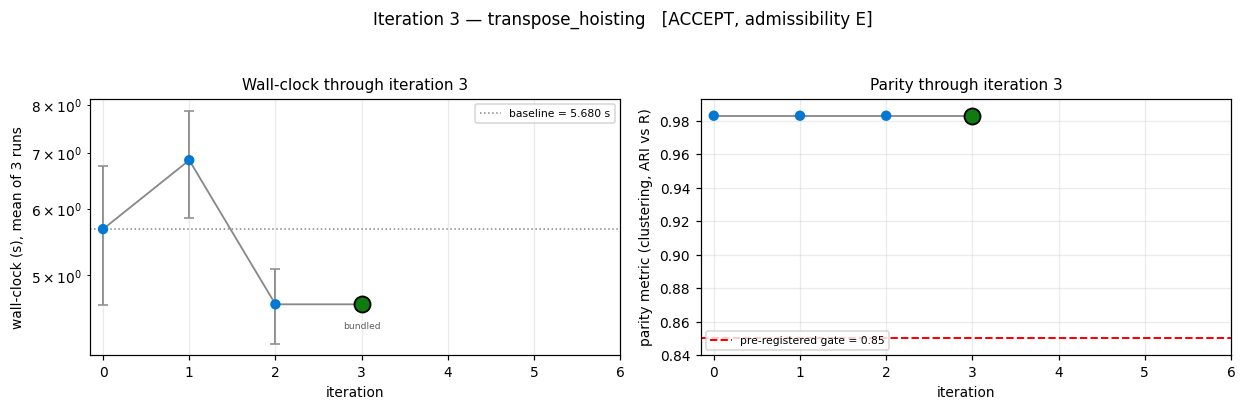

In [7]:
_ = panel(3)
print("\nNOTE from the log:", ITERS[3]["notes"].strip().replace("\n", " "))

## Iteration 4 — `snf_sum_minus_self`: total-minus-self instead of re-summing the other views

R recomputes `Reduce("+", Wall[-j])` for every view `j` inside every diffusion round —
`LW(LW-1)` sparse additions per round. The rewrite forms the total once and subtracts,
`sum_wj = (total - W_j) / (LW - 1)`, which is `2LW - 1` operations: for the fixture's
`LW = 9` cell types that is 17 sparse operations per round instead of 72, and 170
instead of 720 over the default `t = 10` rounds. This is the port's **only (B) bounded
epsilon-approximation** (playbook section 2): identical in exact arithmetic by
associativity, but f64 addition is not associative, so the two orders accumulate
rounding differently. `MATH.md` section 2 derives the ceiling from Higham Thm 2.5 plus
the non-expansiveness of the row-substochastic diffusion map:
`||fused_new - fused_old||_inf <= t * 2u * LW = 2.0e-14`. Expected effect: a 4x cut in
sparse operations inside the hot loop, and a perturbation three orders below the derived
ceiling and eight below the 1e-8 `snf_fused` gate — measured, the fused matrix moved from
2.78e-17 to 4.16e-17 against R and the end-to-end ARI did not change to six decimals.
[ITER_LOG](../ITERATION_LOG.md)

iteration 4: status = ACCEPT, admissibility = bounded (B)
  wall-clock  : 4.6163 s +/- 0.4731 s over runs [4.9625, 4.0772, 4.8093]
  vs baseline : 1.230x end-to-end; SNF2 kernel 1.614x
  parity      : 0.983066 (clears the 0.85 gate); delta vs baseline +0.000000

DERIVED PERTURBATION BOUND (ITERATION_LOG.md::perturbation_bound):
Per Higham Thm 2.5 for summation of n non-negative f64 values,
|sum_hat - sum| <= gamma_{n-1} * sum|w_m|, gamma_k = k*u/(1 - k*u), u = 2^-53.
Original path: gamma_{LW-2} * S. Rewrite: gamma_{LW-1} * S + u * |S - w_j|
<= gamma_{LW} * S. Difference per entry <= 2*u*S / (LW - 1) * LW ~ 2*u*S.
Each W_m is normalize()-d so its rows sum to <= 1 and S <= LW; the map
P_j . (.) . P_j^T followed by normalize() is non-expansive in the inf-norm,
so over t rounds
    ||fused_new - fused_old||_inf <= t * 2 * u * LW
                                   = 10 * 2 * 1.11e-16 * 9 = 2.0e-14.
Full derivation in MATH.md section 2.

measured SNF2 max abs err vs R: baseline 2.78e-17 -> a

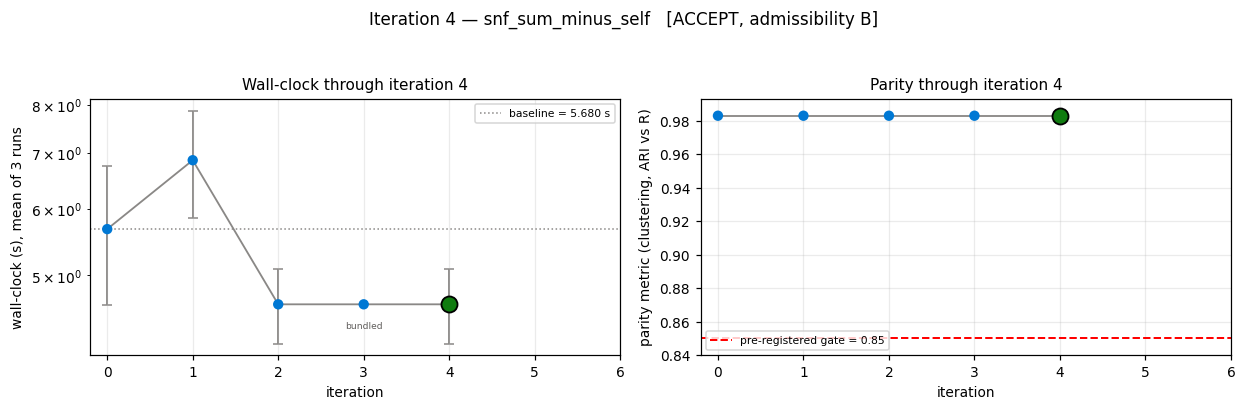

In [8]:
_ = panel(4)
print("\nDERIVED PERTURBATION BOUND (ITERATION_LOG.md::perturbation_bound):")
print(ITERS[4]["perturbation_bound"].strip())
print(f"\nmeasured SNF2 max abs err vs R: baseline "
      f"{ITERS[0]['snf2_max_abs_err_vs_R']:.3g} -> after this rewrite "
      f"{ITERS[4]['snf2_max_abs_err_vs_R']:.3g}  "
      f"(change {abs(ITERS[4]['snf2_max_abs_err_vs_R'] - ITERS[0]['snf2_max_abs_err_vs_R']):.3g}, "
      f"ceiling 2.0e-14)")

## Iteration 5 — `dense_lapack_svd_in_run_pca`: REJECTED and rolled back

This iteration substituted dense LAPACK `np.linalg.svd` for ARPACK `svds` inside
`seuratcompat.run_pca`, on the claim that the rank-`npcs` truncated SVD is simply the
leading block of the thin SVD, so the substitution is **(E) exact** and avoids ARPACK's
iterative restarts on the small (spots x spots) blocks SpatialEcoTyper factorises. The
claim is wrong at the granularity that matters: **a truncated SVD is unique only up to
an orthogonal rotation within a degenerate (or near-degenerate) singular subspace**, and
the two solvers pick different bases inside such a subspace. `FindNeighbors(dims = 1:10)`
cuts the embedding at PC 10, so when a near-degenerate pair straddles the PC-10/PC-11
boundary the two solvers hand different 10-dimensional coordinates to the kNN search, the
SNN graph changes, and the Louvain partition moves with it. End-to-end ARI fell
**0.983066 to 0.924550** — still above the 0.85 gate, which is exactly why a gate alone
is not an admissibility argument. Verdict: `REJECT_INADMISSIBLE`, rolled back. Exact as a
*subspace* is not exact as a *coordinate matrix*, and this pipeline consumes coordinates;
the rewrite was also 6.6x slower here, but that is not the reason for rejection. A
`# NOTE (Acceleration iter 5, ROLLED BACK ...)` comment sits at the call site in
`seuratcompat.run_pca` so nobody retries it. [ITER_LOG](../ITERATION_LOG.md)

iteration 5: status = REJECT_INADMISSIBLE, admissibility = exact (E)
  wall-clock  : 30.7041 s +/- 6.3043 s over runs [32.5709, 23.6772, 35.8642]
  vs baseline : 0.185x end-to-end; SNF2 kernel 1.607x
  parity      : 0.924550 (clears the 0.85 gate); delta vs baseline -0.058516

CLAIMED ADMISSIBILITY (which did not hold):
CLAIM (which turned out to be wrong at the granularity that matters): the
rank-npcs truncated SVD is the leading block of the thin SVD, so replacing
ARPACK `svds` with dense LAPACK `np.linalg.svd` returns the same
factorisation and avoids ARPACK's iterative restarts. SpatialEcoTyper's PCA
operates on (spots x spots) or (spots x <=300) blocks, so dense is cheap.

MATH REASON FOR THE DIP (ITERATION_LOG.md::math_reason_for_dip):
A truncated SVD is unique only up to an orthogonal rotation *within* any
degenerate (or near-degenerate) singular subspace. The two solvers pick
different bases inside such a subspace. `FindNeighbors(dims = 1:10)` cuts the
embedding at PC 10, so wh

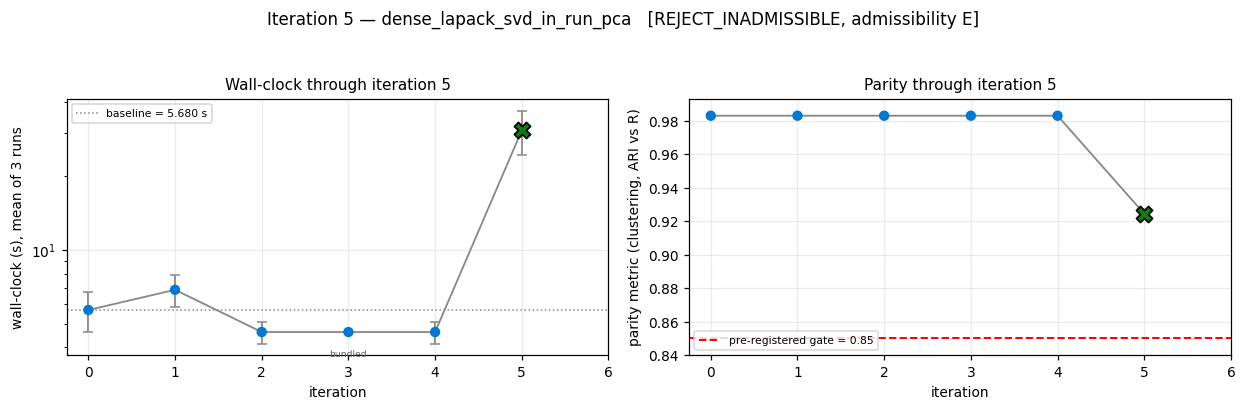

In [9]:
_ = panel(5)
print("\nCLAIMED ADMISSIBILITY (which did not hold):")
print(ITERS[5]["admissibility_evidence"].strip())
print("\nMATH REASON FOR THE DIP (ITERATION_LOG.md::math_reason_for_dip):")
print(ITERS[5]["math_reason_for_dip"].strip())
print(f"\nparity: baseline {ITERS[0]['parity_metric']:.6f} -> "
      f"iter 5 {ITERS[5]['parity_metric']:.6f} "
      f"(delta {ITERS[5]['parity_delta_vs_baseline']:+.6f}); "
      f"still above the {THRESHOLD} gate, and rejected anyway.")

## Iteration 6 — `rank_sparse_vectorised`: one global lexsort for `rankSparse`

`rankSparse` ranks the non-zero entries within each column (`ave(x, col, FUN = rank)`,
average ties); the previous code called `scipy.stats.rankdata` once per column. The
rewrite does one global `np.lexsort((value, column))` and one vectorised tie-averaging
pass — playbook section 1 again. Admissibility is **(E) exact**: ranking within a column
is order-isomorphic to ranking the whole array under a key lexicographic in
`(column, value)`, so the within-column position is `global position - column start`, a
tie group is exactly a maximal run of equal `(column, value)`, and the averages are
computed from the same group boundaries and the same 1-based positions. Expected effect:
a small end-to-end win — `rankSparse` is only 0.05 s of R's 13.8 s on this crop — with
provably identical ranks. Measured: 1.03x on the step, and the independent check
`test_exact_match.py::test_rank_sparse` reports **0.0** against R at the pre-registered
`deterministic-strict` 1e-13 gate. [ITER_LOG](../ITERATION_LOG.md)

iteration 6: status = ACCEPT, admissibility = exact (E)
  wall-clock  : 4.5000 s +/- 0.5291 s over runs [4.2676, 5.1055, 4.1268]
  vs baseline : 1.262x end-to-end; SNF2 kernel 1.582x
  parity      : 0.983066 (clears the 0.85 gate); delta vs baseline +0.000000


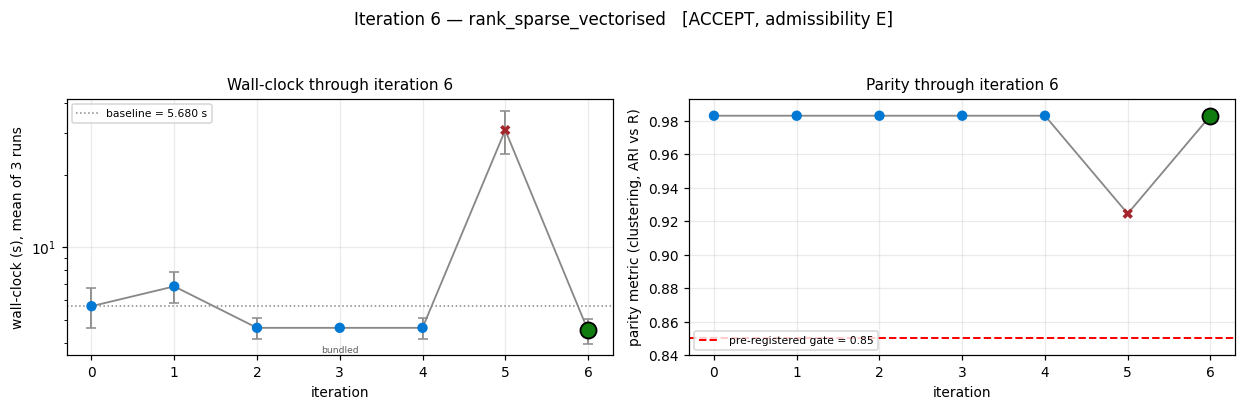

In [10]:
_ = panel(6)

## Aggregate evolution figure

The final cell re-renders the two-panel aggregate that `engine.plot_evolution` writes to
`examples/evolution.png` — wall-clock versus iteration on top, parity versus iteration
with the pre-registered threshold below — directly from `ITERATION_LOG.md`, saves it to
disk, and displays it inline. Only baseline and accepted iterations appear in that
figure by the kit's convention; the rejected iteration 5 is documented in its own
section above and in the summary table below.

In [11]:
from engine.plot_evolution import parse_log, plot  # noqa: E402
from pathlib import Path  # noqa: E402

entries = parse_log(Path(LOG_PATH))
print(f"engine.plot_evolution parsed {len(entries)} entries: "
      f"{[(e.iter, e.status) for e in entries]}")

OUT_PNG = Path(ROOT) / "examples" / "evolution.png"
# Rendered under stock matplotlib defaults so the file is byte-for-byte what
# `python -m engine.plot_evolution --port-dir .` writes, not what this notebook's
# rcParams would produce.
import matplotlib  # noqa: E402

with plt.rc_context(matplotlib.rcParamsDefault):
    plot(entries, OUT_PNG, threshold=THRESHOLD)
print(f"wrote {OUT_PNG} ({OUT_PNG.stat().st_size} bytes)")

engine.plot_evolution parsed 7 entries: [(0, 'baseline'), (1, 'ACCEPT'), (2, 'ACCEPT'), (3, 'ACCEPT'), (4, 'ACCEPT'), (5, 'REJECT_INADMISSIBLE'), (6, 'ACCEPT')]


[plot] wrote /scratch/users/steorra/analysis/omicverse_dev/py-spatialecotyper/examples/evolution.png
wrote /scratch/users/steorra/analysis/omicverse_dev/py-spatialecotyper/examples/evolution.png (79453 bytes)


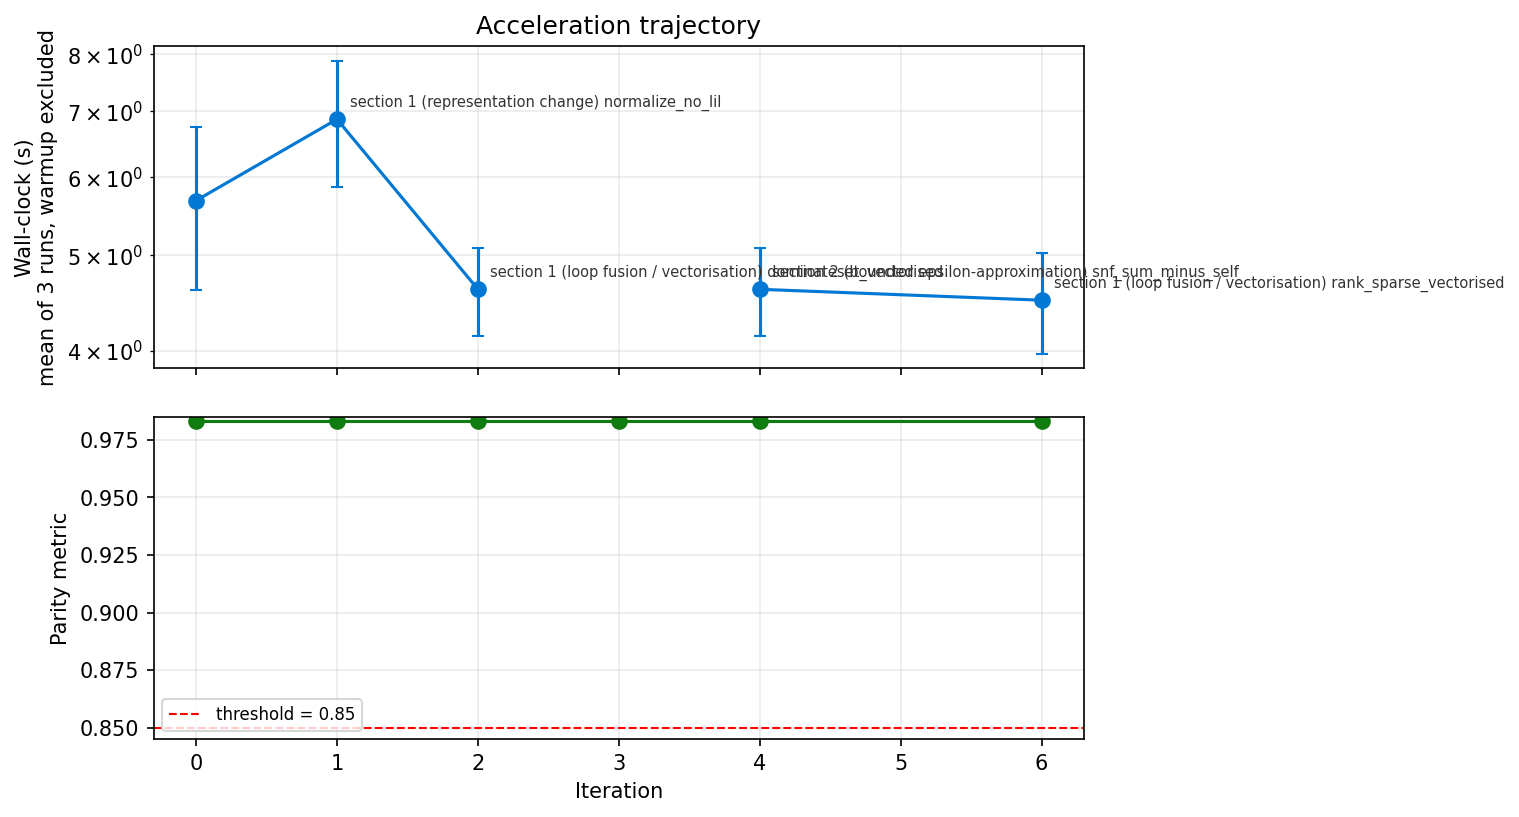

In [12]:
from IPython.display import Image, display  # noqa: E402

display(Image(filename=str(OUT_PNG)))

In [13]:
final = summary.copy()
final["gate"] = THRESHOLD
final["parity passes"] = [ITERS[i]["parity_passes"] for i in final.index]
print("Acceleration record, one row per iteration (parsed from ITERATION_LOG.md):")
print(final.to_string())

base_w = ITERS[0]["_wall"]
last = ITERS[max(ACCEPTED)]
print(f"\ncumulative, baseline -> last accepted (iteration {max(ACCEPTED)}):")
print(f"  end-to-end wall-clock : {base_w:.4f} s -> {last['_wall']:.4f} s "
      f"({base_w / last['_wall']:.2f}x)")
print(f"  SNF2 kernel           : {ITERS[0]['snf2_only_s']:.4f} s -> "
      f"{last['snf2_only_s']:.4f} s "
      f"({ITERS[0]['snf2_only_s'] / last['snf2_only_s']:.2f}x)")
print(f"  parity (ARI vs R)     : {ITERS[0]['parity_metric']:.6f} -> "
      f"{last['parity_metric']:.6f} "
      f"(delta {last['parity_metric'] - ITERS[0]['parity_metric']:+.6f})")
print(f"  iterations accepted   : {len(ACCEPTED) - 1} of "
      f"{len(ITERS) - 1} attempted; rejected: {len(REJECTED)} "
      f"({', '.join(ITERS[i]['action'] for i in REJECTED)})")
print(f"  sum of admitted (B) bounds: 2.0e-14 (MATH.md section 2), against the 1e-8 "
      f"deterministic-standard gate for snf_fused")

Acceleration record, one row per iteration (parsed from ITERATION_LOG.md):
                           action                                   playbook class  wall mean (s)  wall stddev (s)  SNF2 only (s)  speedup vs baseline  parity (ARI)               status  gate  parity passes
iter                                                                                                                                                                                                          
0                      (baseline)                                          -     -         5.6797           1.0702         1.1257                  NaN      0.983066             baseline  0.85           True
1                normalize_no_lil          section 1 (representation change)     E         6.8673           1.0055         0.9864                 1.14      0.983066               ACCEPT  0.85           True
2          dominateset_vectorised    section 1 (loop fusion / vectorisation)     E         4.6163

### Stop reason

Reproduced verbatim from the end of [`ITERATION_LOG.md`](../ITERATION_LOG.md):

In [14]:
stop = LOG_TEXT.split("## Stop reason", 1)[1].strip()
print(stop)

Last accepted rewrite (iter 6) produced a 1.03x step; the remaining playbook
candidates for this pipeline are either already applied, inadmissible (iter 5),
or would change the numerics that the gate protects. The dominant remaining
cost is `scipy.spatial.cKDTree` in `getSN` and the Louvain sweep in
`_modularity`, neither of which has an equivalence-preserving rewrite left in
the playbook that does not touch neighbour selection.
